In [1]:
import pandas as pd
import numpy as np

MANUALLY_PREPROCESSED_CSV_DATA_FILE_PATH: str = "..\\data\\original.csv"

df = pd.read_csv(MANUALLY_PREPROCESSED_CSV_DATA_FILE_PATH, sep=";", decimal=",")

# 1. Exploratory Data Analysis
### 1.1. Initial Cleanup
Some issues with the data were fixed in excel manually. These include:
- Table was not aligned to the top left.
- A span of ~400 rows was shifted to the right.

We decided to remove columns with invalid or missing values completely, as there were only 122 such rows. The values appeard to be missing completely at random.

In [2]:
# Coerce invalid values to NaN
object_feature_columns = ["Magnesium_mg", "VitE_mg"]
coerced_count = 0
for col in object_feature_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    coerced_count += np.sum(df[col].isna())
print(f"Coerced {coerced_count} values to NaN in columns {object_feature_columns}.")

# Remove rows with NaN values
row_has_none = df.isna().any(axis=1)
df = df.dropna()
print(f"Dropped {sum(row_has_none)} rows with missing values.")

# Define numeric columns for future use
num_cols = df.select_dtypes("number").columns

# Coercing duplicate rows
grouped_rows = list(df.groupby("NDB_No", dropna=False, sort=False))
original_row_count = len(df)
merged_rows = []
for ndb_no, group in grouped_rows:
    if len(group) != 1:
        for column in df.columns:
            if group[column].astype(str).nunique() != 1:
                raise ValueError(f"Multiple non-matching rows found for NDB_NO: {ndb_no}")

    merged_rows.append(group.iloc[0])

df = pd.DataFrame(merged_rows, columns=df.columns).reset_index(drop=True)
print(f"Removed {original_row_count - len(df)} duplicate rows.")

# Convert micro-/mili-grams to grams (automatic, based on suffixes)
suffix_map = {"_mg": 1e-3, "_mcg": 1e-6}
converted = []
for col in list(df.columns):
    for suf, factor in suffix_map.items():
        if col.endswith(suf):
            base = col.rsplit("_", 1)[0]
            new_col = f"{base}_g"
            # ensure numeric before conversion
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[new_col] = df[col] * factor
            converted.append((col, new_col))
            # drop the original suffixed column after conversion
            df.drop(columns=[col], inplace=True)
            break

print(f"Converted {len(converted)} columns: {converted}")

# Recompute numeric columns
num_cols = df.select_dtypes("number").columns.tolist()

Coerced 15 values to NaN in columns ['Magnesium_mg', 'VitE_mg'].
Dropped 122 rows with missing values.
Removed 916 duplicate rows.
Converted 20 columns: [('Calcium_mg', 'Calcium_g'), ('Iron_mg', 'Iron_g'), ('Magnesium_mg', 'Magnesium_g'), ('Phosphorus_mg', 'Phosphorus_g'), ('Potassium_mg', 'Potassium_g'), ('Sodium_mg', 'Sodium_g'), ('Zinc_mg', 'Zinc_g'), ('Copper_mcg', 'Copper_g'), ('Manganese_mg', 'Manganese_g'), ('Selenium_mcg', 'Selenium_g'), ('VitC_mg', 'VitC_g'), ('Thiamin_mg', 'Thiamin_g'), ('Riboflavin_mg', 'Riboflavin_g'), ('Niacin_mg', 'Niacin_g'), ('VitB6_mg', 'VitB6_g'), ('Folate_mcg', 'Folate_g'), ('VitB12_mcg', 'VitB12_g'), ('VitA_mcg', 'VitA_g'), ('VitE_mg', 'VitE_g'), ('VitD2_mcg', 'VitD2_g')]


### 1.2. Outliers
Most features have visible outliers, we will need to resolve those later.

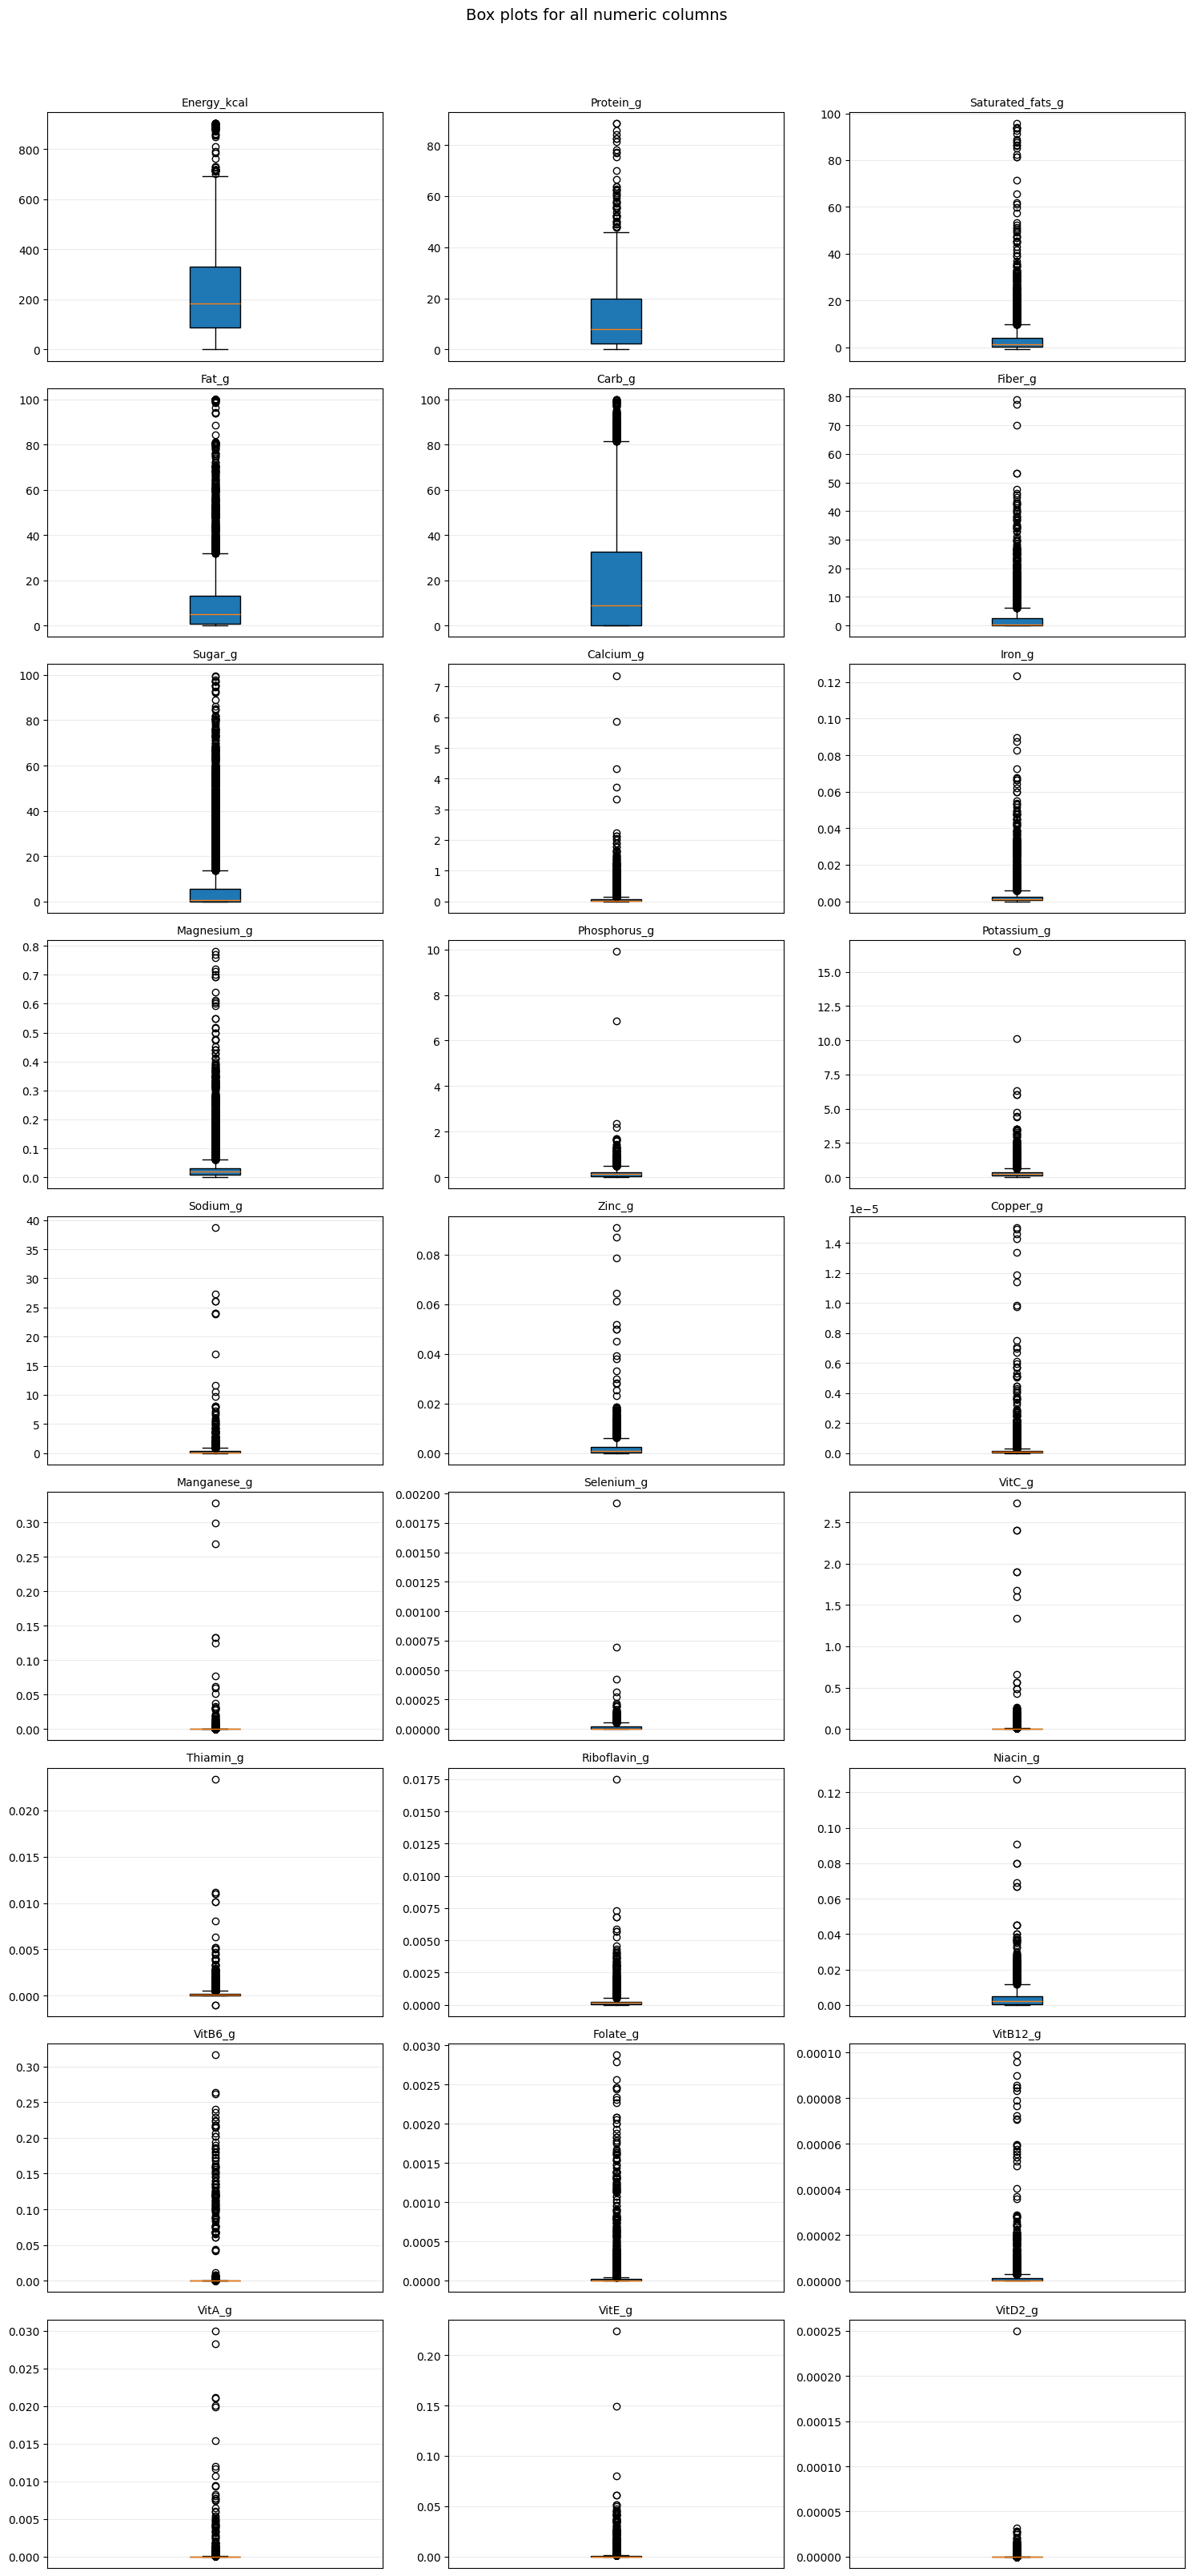

In [3]:
import math
import matplotlib.pyplot as plt

# Box plots for all numeric columns
numeric_data = df[num_cols]
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, column in zip(axes, num_cols):
    series = numeric_data[column].dropna()
    ax.boxplot(series, vert=True, patch_artist=True)
    ax.set_title(column, fontsize=10)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.25)

for ax in axes[len(num_cols):]:
    ax.axis("off")

fig.suptitle("Box plots for all numeric columns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.3. Pyramid charts
- Idea taken from Hynek Vaverka group's first presentation.
- We can see most foods recpect the minimum calory estimate:
$$\text{kcal} \ge 4\cdot \text{carbs} + 4\cdot \text{protein} + 9\cdot \text{fat} + 7\cdot \text{alcohol}$$
- However, some foods are in forbidden regions of the graphs (a food can't have 100 grams of carbs but 0 calories).

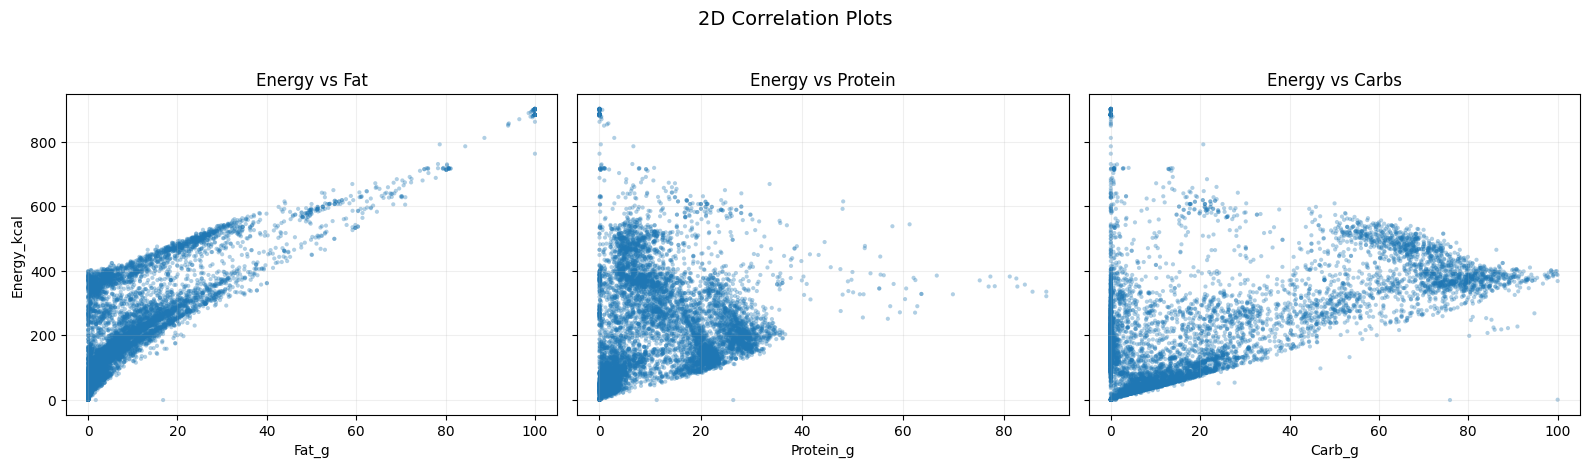

In [4]:
import matplotlib.pyplot as plt

# Simple 2D plots for Energy vs macronutrients (pyramid-like patterns)
pairs = [
    ("Fat_g", "Energy vs Fat"),
    ("Protein_g", "Energy vs Protein"),
    ("Carb_g", "Energy vs Carbs"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (x_col, title) in zip(axes, pairs):
    plot_df = df[[x_col, "Energy_kcal"]].copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df["Energy_kcal"] = pd.to_numeric(plot_df["Energy_kcal"], errors="coerce")
    plot_df = plot_df.dropna()

    ax.scatter(
        plot_df[x_col],
        plot_df["Energy_kcal"],
        s=9,
        alpha=0.35,
        edgecolors="none"
    )
    ax.set_xlabel(x_col)
    ax.set_title(title)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Energy_kcal")
fig.suptitle("2D Correlation Plots", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 1.4. Feature Correlation

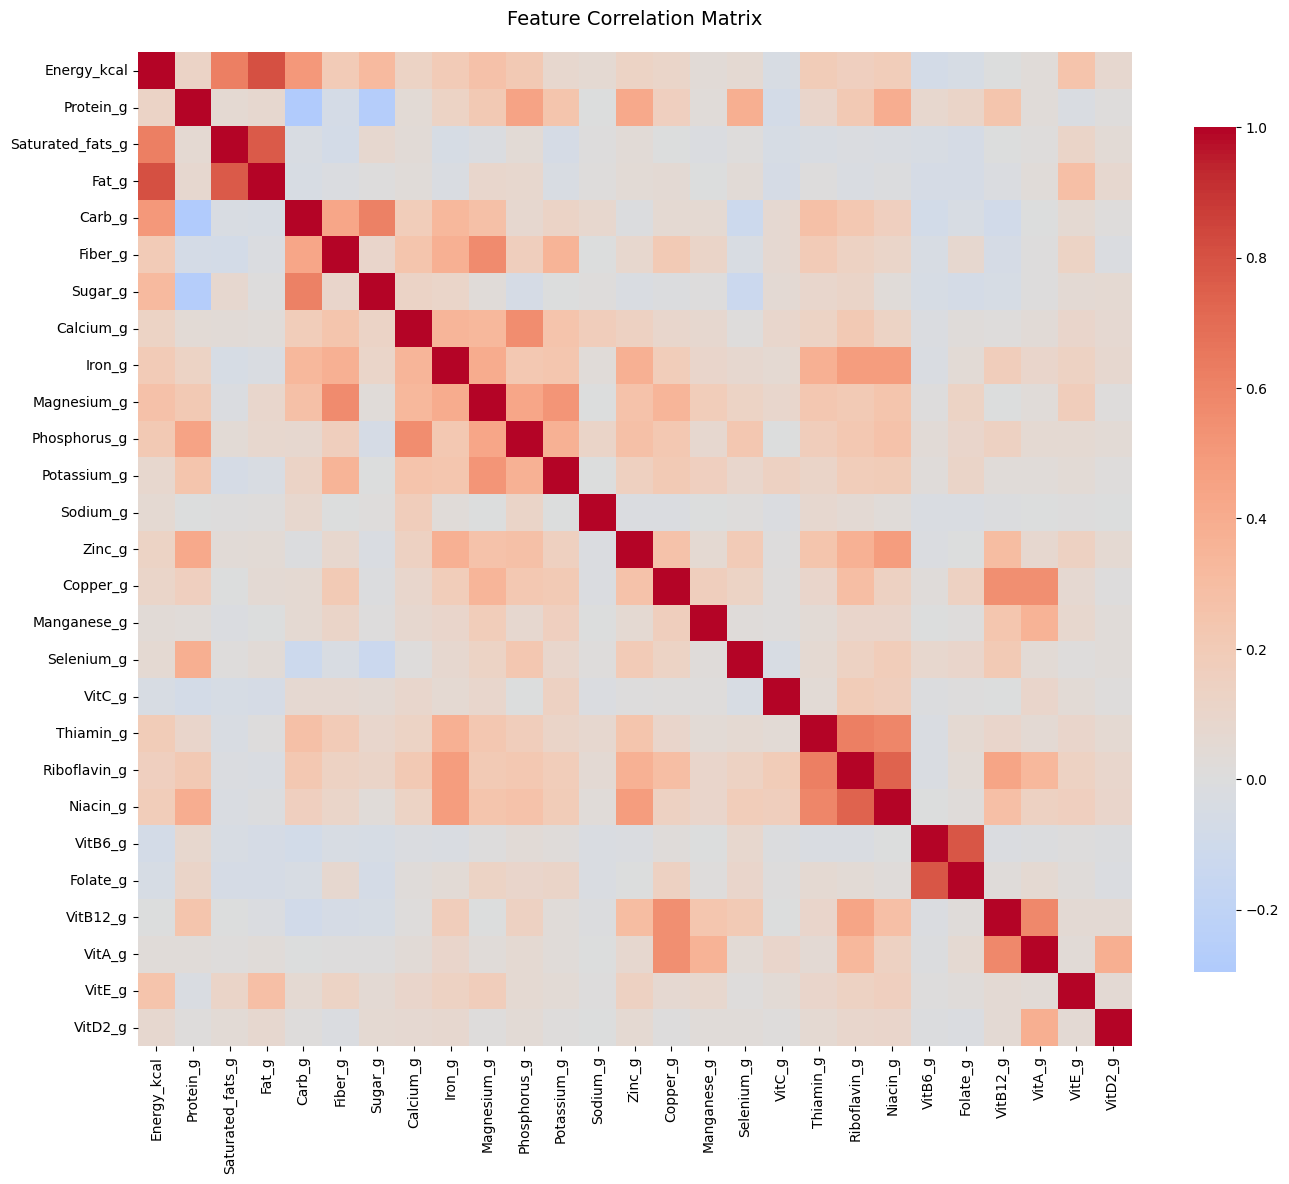

Highly correlated pairs (>0.95): 0


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df[num_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (>0.95)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"Highly correlated pairs (>0.95): {len(high_corr_pairs)}")
for col1, col2, val in high_corr_pairs[:5]:
    print(f"  {col1} <-> {col2}: {val:.3f}")

### 1.5. 3D PCA Scatter (Nutrients, Minerals, Vitamins)

In [6]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# Categorize features
nutrients = [c for c in num_cols if any(x in c.lower() for x in ['energy', 'protein', 'fat', 'carb', 'fiber', 'sugar'])]
minerals = [c for c in num_cols if any(x in c.lower() for x in ['calcium', 'iron', 'magnesium', 'phosphorus', 'potassium', 'sodium', 'zinc', 'copper', 'manganese', 'selenium'])]
vitamins = [c for c in num_cols if any(x in c.lower() for x in ['vit', 'thiamin', 'riboflavin', 'niacin', 'folate'])]

print(f"Nutrients: {len(nutrients)}, Minerals: {len(minerals)}, Vitamins: {len(vitamins)}")

# Apply PCA to each group (1 component each)
pca_nut = PCA(n_components=1).fit_transform(df[nutrients]).flatten()
pca_min = PCA(n_components=1).fit_transform(df[minerals]).flatten()
pca_vit = PCA(n_components=1).fit_transform(df[vitamins]).flatten()

# Remove 99th percentile outliers for better visibility
p99_nut = np.percentile(np.abs(pca_nut), 99)
p99_min = np.percentile(np.abs(pca_min), 99)
p99_vit = np.percentile(np.abs(pca_vit), 99)

mask = (np.abs(pca_nut) <= p99_nut) & (np.abs(pca_min) <= p99_min) & (np.abs(pca_vit) <= p99_vit)
pca_nut_filt = pca_nut[mask]
pca_min_filt = pca_min[mask]
pca_vit_filt = pca_vit[mask]

print(f"Removed {(~mask).sum()} outliers (99th percentile), kept {mask.sum()} points")

# Interactive 3D scatter with Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=pca_nut_filt,
    y=pca_min_filt,
    z=pca_vit_filt,
    mode='markers',
    marker=dict(
        size=4,
        color=pca_nut_filt,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Nutrient PC1')
    ),
    text=[f'Nut: {n:.2f}<br>Min: {m:.2f}<br>Vit: {v:.2f}' for n, m, v in zip(pca_nut_filt, pca_min_filt, pca_vit_filt)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D PCA Scatter: Nutrients vs Minerals vs Vitamins (Interactive)',
    scene=dict(
        xaxis_title='Nutrients (PC1)',
        yaxis_title='Minerals (PC1)',
        zaxis_title='Vitamins (PC1)',
    ),
    width=1000,
    height=800
)

fig

Nutrients: 7, Minerals: 10, Vitamins: 10
Removed 278 outliers (99th percentile), kept 8935 points


# 2. Preprocessing
In addition to the issues above, we will also explore the impact of using the log-transform on some highly skewd columns. We will compare the clustering results on both transformed and not transformed columns. Additionally, we will use RobustScaler, as it is *\*drumroll\**, Robust (to outliers). 

In [ ]:
from sklearn.preprocessing import RobustScaler

# Start from numeric features and drop obvious identifier columns
id_like_cols = [c for c in ["NDB_No"] if c in df.columns]
X = df.select_dtypes(include="number").drop(columns=id_like_cols, errors="ignore").copy()
print(f"Initial numeric shape: {X.shape}, removed id-like columns: {len(id_like_cols)}")

# Keep outliers and rely on RobustScaler; only clean clearly invalid negatives
neg_values = int((X < 0).sum().sum())
X = X.clip(lower=0)
print(f"Clamped negative values to 0: {neg_values}")

# Robust scaling without log transform
scaler_nonlog = RobustScaler()
X_nonlog_scaled = pd.DataFrame(
    scaler_nonlog.fit_transform(X),
    index=X.index,
    columns=X.columns,
 )
print(f"Scaled values (non-log): {X_nonlog_scaled.size}")

# Select columns for log1p: non-negative + positively skewed
skew_threshold = 1.0
log_cols = X.skew(numeric_only=True)
log_cols = log_cols[log_cols > skew_threshold].index.tolist()

X_log1p = X.copy()
if log_cols:
    X_log1p[log_cols] = np.log1p(X_log1p[log_cols])
print(f"log1p-transformed columns: {len(log_cols)}, transformed values: {len(log_cols) * len(X_log1p)}")

# Robust scaling after log1p transform
scaler_log1p = RobustScaler()
X_log1p_scaled = pd.DataFrame(
    scaler_log1p.fit_transform(X_log1p),
    index=X_log1p.index,
    columns=X_log1p.columns,
 )
print(f"Scaled values (log1p): {X_log1p_scaled.size}")

# Keep both datasets ready for downstream clustering
datasets = {
    "nonlog": X_nonlog_scaled,
    "log1p": X_log1p_scaled,
}
print(f"Prepared datasets: {list(datasets.keys())}, shape: {X_nonlog_scaled.shape}")

Initial numeric shape: (9213, 27), removed id-like columns: 1
Clamped negative values to 0: 10
Scaled values (non-log): 248751
log1p-transformed columns: 27, transformed values: 248751
Scaled values (log1p): 248751
Prepared datasets: ['nonlog', 'log1p'], shape: (9213, 27)


### 2.1. Before/afer log1p

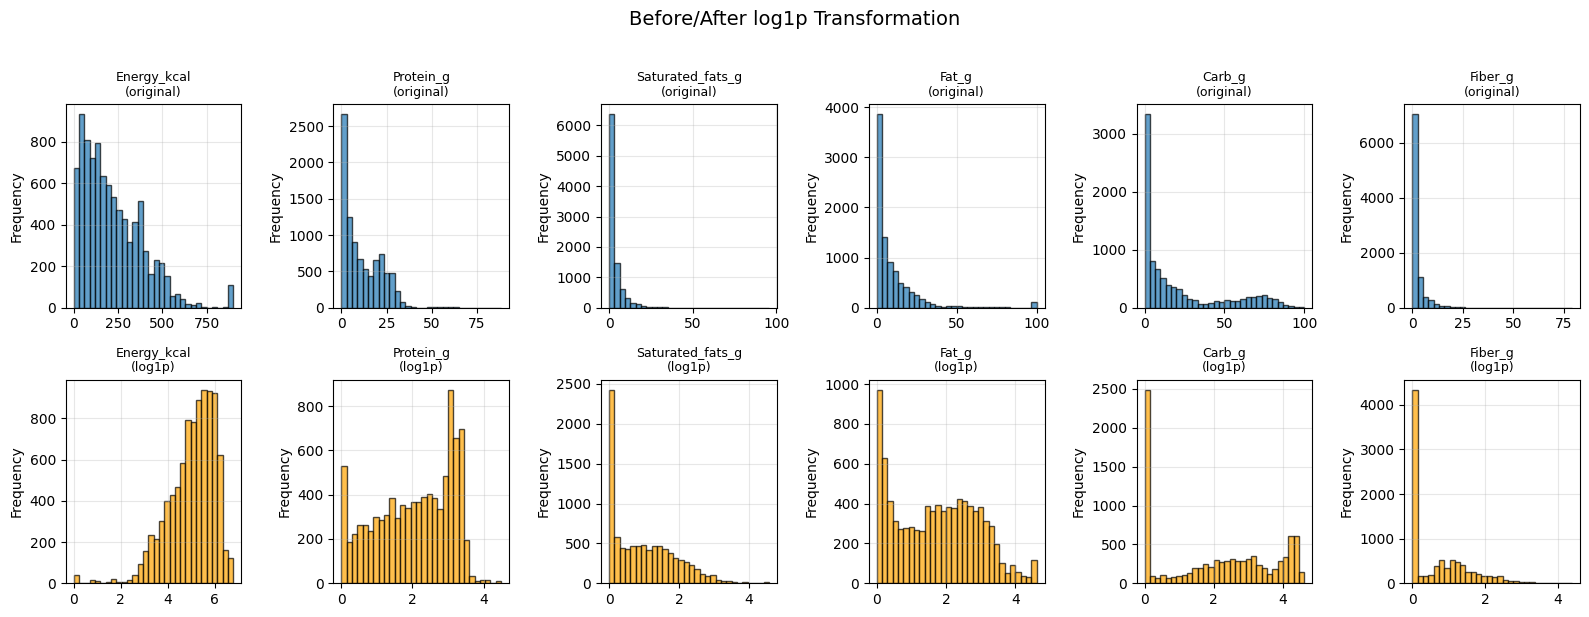

Visualized 6 most skewed columns


In [ ]:
# Compare log1p impact on a few key skewed columns
sample_cols = [c for c in log_cols if c in num_cols][:6]

fig, axes = plt.subplots(2, len(sample_cols), figsize=(16, 6))

for idx, col in enumerate(sample_cols):
    # Before log1p
    axes[0, idx].hist(X[col], bins=30, alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{col}\n(original)', fontsize=9)
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(alpha=0.3)
    
    # After log1p
    axes[1, idx].hist(X_log1p[col], bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1, idx].set_title(f'{col}\n(log1p)', fontsize=9)
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(alpha=0.3)

fig.suptitle('Before/After log1p Transformation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Visualized {len(sample_cols)} most skewed columns")

### 2.2. Feature engineering

In [ ]:
# Create feature-engineered versions
X_eng = X.copy()

# Ratios: nutrient density
if 'Energy_kcal' in X_eng.columns and 'Protein_g' in X_eng.columns:
    X_eng['Protein_per_kcal'] = X_eng['Protein_g'] / (X_eng['Energy_kcal'] + 1e-8)
if 'Fiber_g' in X_eng.columns and 'Carb_g' in X_eng.columns:
    X_eng['Fiber_Carb_ratio'] = X_eng['Fiber_g'] / (X_eng['Carb_g'] + 1e-8)
if 'Saturated_fats_g' in X_eng.columns and 'Fat_g' in X_eng.columns:
    X_eng['Saturated_fat_ratio'] = X_eng['Saturated_fats_g'] / (X_eng['Fat_g'] + 1e-8)

# Mineral density (total minerals per 100g estimate)
mineral_cols_eng = [c for c in minerals if c in X.columns]
if mineral_cols_eng:
    X_eng['Mineral_density'] = X_eng[mineral_cols_eng].sum(axis=1)

# Vitamin density
vitamin_cols_eng = [c for c in vitamins if c in X.columns]
if vitamin_cols_eng:
    X_eng['Vitamin_density'] = X_eng[vitamin_cols_eng].sum(axis=1)

print(f"Created engineered features: {[c for c in X_eng.columns if c not in X.columns]}")
print(f"Total features after engineering: {X_eng.shape[1]}")
print(f"\nNew feature stats:\n{X_eng[[c for c in X_eng.columns if c not in X.columns]].describe()}")

Created engineered features: ['Protein_per_kcal', 'Fiber_Carb_ratio', 'Saturated_fat_ratio', 'Mineral_density', 'Vitamin_density']
Total features after engineering: 32

New feature stats:
       Protein_per_kcal  Fiber_Carb_ratio  Saturated_fat_ratio  \
count      9.213000e+03       9213.000000          9213.000000   
mean       4.130034e+05          0.107578           336.758535   
std        2.995985e+07          0.239166          7577.613954   
min        0.000000e+00          0.000000             0.000000   
25%        1.811765e-02          0.000000             0.158416   
50%        4.343891e-02          0.020383             0.265347   
75%        1.050877e-01          0.112644             0.380284   
max        2.644000e+09          4.498581        300000.000000   

       Mineral_density  Vitamin_density  
count      9213.000000      9213.000000  
mean          0.832923         0.015311  
std           1.159151         0.067860  
min           0.000000         0.000000  
25%    

# 3. Models
## 3.1. Baseline - KMeans

In [8]:
# Baseline KMeans (k=4) — concise
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

RANDOM_STATE = 42

# Prepare scaled matrix (reuse prepared datasets if available)
if 'X_drop' not in globals():
    if 'datasets' in globals() and 'nonlog' in datasets:
        X_drop = datasets['nonlog']
    else:
        drop_mask = df[num_cols].notna().all(axis=1)
        X_drop_raw = df.loc[drop_mask, num_cols].astype(float)
        drop_scaler = RobustScaler()
        X_drop = pd.DataFrame(drop_scaler.fit_transform(X_drop_raw), columns=num_cols, index=X_drop_raw.index)

# Fit KMeans k=4
km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
labels_k4 = km4.fit_predict(X_drop)

# Build human-readable analysis frame
drop_mask = df[num_cols].notna().all(axis=1)
analysis_df = df.loc[drop_mask, num_cols].astype(float).copy()
analysis_df['cluster'] = labels_k4
if 'Descrip' in df.columns:
    analysis_df['Descrip'] = df.loc[drop_mask, 'Descrip'].values
if 'NDB_No' in df.columns:
    analysis_df['NDB_No'] = df.loc[drop_mask, 'NDB_No'].values

# Cluster themes (z-delta top +/-)
overall_mean = analysis_df[num_cols].mean()
global_std = analysis_df[num_cols].std().replace(0, np.nan)
rows = []
for cid in sorted(analysis_df['cluster'].unique()):
    z = ((analysis_df.groupby('cluster')[num_cols].mean().loc[cid] - overall_mean) / global_std).replace([np.inf, -np.inf], np.nan).fillna(0)
    up = z.sort_values(ascending=False).head(3)
    down = z.sort_values(ascending=True).head(3)
    rows.append({'cluster': cid, 'top_positive': ', '.join([f"{f}({v:.2f})" for f,v in up.items()]), 'top_negative': ', '.join([f"{f}({v:.2f})" for f,v in down.items()])})

display(pd.DataFrame(rows))

# Representative ingredients (closest to centroids)
centroids = pd.DataFrame(km4.cluster_centers_, columns=X_drop.columns)
dists = pairwise_distances(X_drop, centroids)
reps = []
for cid in range(km4.n_clusters):
    mask = (labels_k4 == cid)
    if not mask.any():
        continue
    member_dists = dists[mask, cid]
    member_idx = np.flatnonzero(mask)
    nearest = np.argsort(member_dists)[:5]
    idxs = member_idx[nearest]
    reps.append(pd.DataFrame({'cluster': cid, 'rank': np.arange(1, len(idxs)+1), 'NDB_No': analysis_df.iloc[idxs].get('NDB_No').values, 'ingredient': analysis_df.iloc[idxs].get('Descrip').values, 'distance': member_dists[nearest]}))

if reps:
    display(pd.concat(reps, ignore_index=True))

# Cluster sizes
sizes = analysis_df['cluster'].value_counts().sort_index()
display(pd.concat([sizes, (100 * sizes / sizes.sum()).rename('pct')], axis=1).round(2))

,cluster,top_positive,top_negative
0,0,"Carb_g(0.01), Energy_kcal(0.01), Fat_g(0.01)","VitB6_g(-0.10), Folate_g(-0.09), VitA_g(-0.03)"
1,1,"VitB6_g(8.70), Folate_g(7.73), Selenium_g(0.84)","Carb_g(-0.80), Energy_kcal(-0.71), Fat_g(-0.51)"
2,2,"VitA_g(25.09), Copper_g(15.07), VitB12_g(14.00)","Carb_g(-0.70), Sugar_g(-0.48), Fiber_g(-0.48)"
3,3,"VitC_g(30.79), Riboflavin_g(4.18), Niacin_g(4.01)","Fat_g(-0.60), Protein_g(-0.59), Saturated_fats..."


,cluster,rank,NDB_No,ingredient,distance
0,0,1,21227,pizza meat veg topping rising crust frz ckd,2.502218
1,0,2,22954,egg rolls chick refr htd,2.694678
2,0,3,36619,restaurant chinese kung pao chick,2.760366
3,0,4,21226,pizza meat veg topping reg crust frz ckd,2.809372
4,0,5,22903,pizza pepperoni topping reg crust frz ckd,3.126554
5,1,1,P039,mullet,12.652557
6,1,2,P023,kalava,13.018203
7,1,3,P016,guitar fish,13.701317
8,1,4,P013,chembali,22.213204
9,1,5,P038,moon fish,27.948759


,count,pct
cluster,,
0,9091,98.68
1,104,1.13
2,10,0.11
3,8,0.09


Selected: X_drop — silhouette=0.9485, min_cluster_ratio=0.0009
Cluster sizes:
0    9091
1     104
2      10
3       8


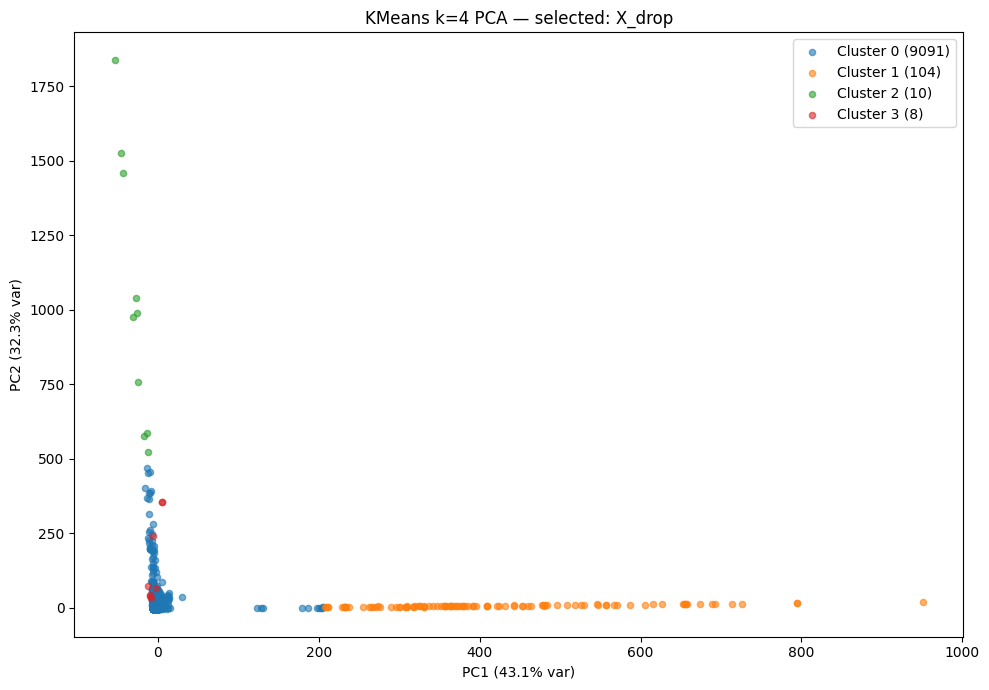

,count,pct
cluster,,
0,9091,98.68
1,104,1.13
2,10,0.11
3,8,0.09


In [9]:
# Iterate KMeans variants (log1p vs nonlog vs X_drop) and plot 2D PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

# Collect candidate feature matrices
cands = {}
if 'datasets' in globals():
    for n in ('log1p', 'nonlog'):
        if n in datasets:
            cands[n] = datasets[n]
if 'X_drop' in globals():
    cands['X_drop'] = X_drop
# fallback
if not cands:
    drop_mask = df[num_cols].notna().all(axis=1)
    X_drop_raw = df.loc[drop_mask, num_cols].astype(float)
    drop_scaler = RobustScaler()
    cands['X_drop'] = pd.DataFrame(drop_scaler.fit_transform(X_drop_raw), columns=num_cols, index=X_drop_raw.index)

results = []
for name, X in cands.items():
    if X.shape[0] < 4:
        continue
    km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
    labels = km.fit_predict(X)
    sil = None
    try:
        if len(np.unique(labels)) > 1 and X.shape[0] > len(np.unique(labels)):
            sil = silhouette_score(X, labels)
    except Exception:
        sil = None
    sizes = pd.Series(labels).value_counts().sort_index()
    balance = sizes.min() / sizes.sum()
    results.append({'name': name, 'sil': -1 if sil is None else sil, 'balance': balance, 'sizes': sizes, 'km': km, 'labels': labels, 'X': X})

# choose best by silhouette then by balance
results = sorted(results, key=lambda r: (r['sil'], r['balance']), reverse=True)
best = results[0]
name = best['name']
km4 = best['km']
labels_k4 = best['labels']
X_drop = best['X']

print(f"Selected: {name} — silhouette={best['sil']:.4f}, min_cluster_ratio={best['balance']:.4f}")
print('Cluster sizes:')
print(best['sizes'].to_string())

# 2D PCA plot colored by cluster
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_drop)
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10
for cid in sorted(np.unique(labels_k4)):
    m = labels_k4 == cid
    ax.scatter(coords[m, 0], coords[m, 1], s=20, alpha=0.6, c=[colors(cid)], label=f"Cluster {cid} ({m.sum()})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"KMeans k=4 PCA — selected: {name}")
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# store labels in analysis_df for convenience
drop_mask = df[num_cols].notna().all(axis=1)
analysis_df = df.loc[drop_mask, num_cols].astype(float).copy()
analysis_df['cluster'] = labels_k4
if 'Descrip' in df.columns:
    analysis_df['Descrip'] = df.loc[drop_mask, 'Descrip'].values
if 'NDB_No' in df.columns:
    analysis_df['NDB_No'] = df.loc[drop_mask, 'NDB_No'].values

# show sizes table
sizes = analysis_df['cluster'].value_counts().sort_index()
display(pd.concat([sizes, (100 * sizes / sizes.sum()).rename('pct')], axis=1).round(2))

Strategy ranking (top 6):
  name variant      sil  balance    score
X_drop   pca10 0.953056 0.000868 0.953925
X_drop    full 0.948466 0.000868 0.949335

Selected strategy: X_drop / pca10 — sil=0.9531, balance=0.0009


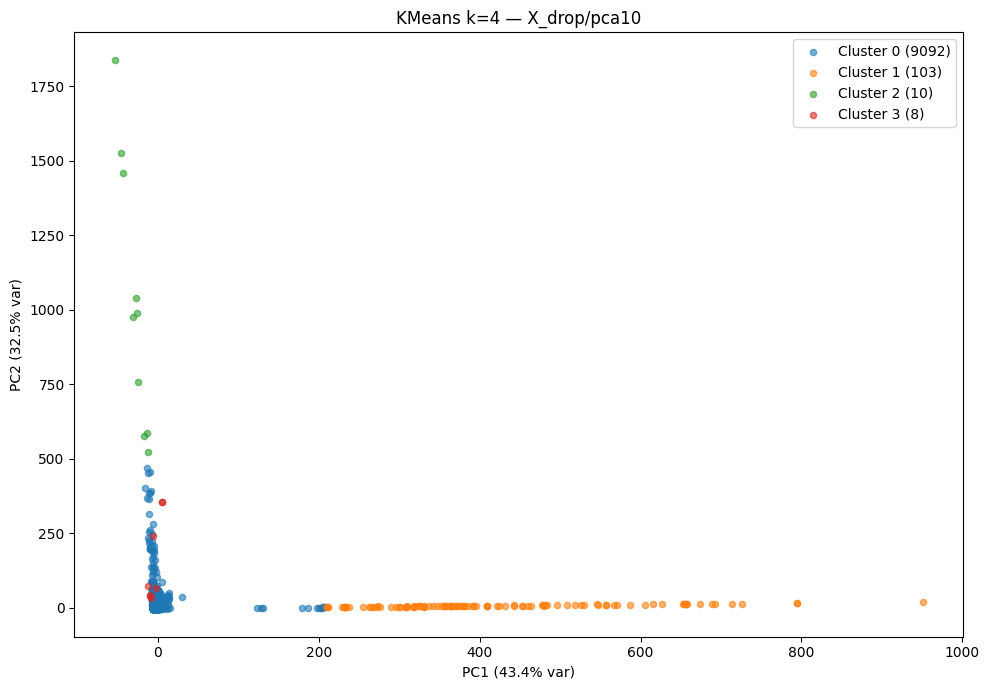

,count,pct
cluster,,
0,9092,98.69
1,103,1.12
2,10,0.11
3,8,0.09


In [10]:
# Sweep clustering strategies to improve balance (k=4)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Build candidates
cands = {}
if 'datasets' in globals():
    for k in ('log1p', 'nonlog'):
        if k in datasets:
            cands[k] = datasets[k]
if 'X_drop' in globals():
    cands['X_drop'] = X_drop
# fallback
if not cands:
    drop_mask = df[num_cols].notna().all(axis=1)
    X_drop_raw = df.loc[drop_mask, num_cols].astype(float)
    from sklearn.preprocessing import RobustScaler
    drop_scaler = RobustScaler()
    cands['X_drop'] = pd.DataFrame(drop_scaler.fit_transform(X_drop_raw), columns=num_cols, index=X_drop_raw.index)

results = []
for name, X in cands.items():
    # variants: full, PCA(10)
    for variant in ('full', 'pca10'):
        X_use = X.values if variant == 'full' else PCA(n_components=min(10, X.shape[1]), random_state=RANDOM_STATE).fit_transform(X)
        if X_use.shape[0] < 4:
            continue
        km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
        labels = km.fit_predict(X_use)
        sizes = pd.Series(labels).value_counts().sort_index()
        balance = sizes.min() / sizes.sum()
        sil = np.nan
        try:
            if len(np.unique(labels)) > 1 and X_use.shape[0] > len(np.unique(labels)):
                sil = silhouette_score(X_use, labels)
        except Exception:
            sil = np.nan
        score = (0 if np.isnan(sil) else sil) + balance  # simple combined
        results.append({'name': name, 'variant': variant, 'sil': sil, 'balance': balance, 'score': score, 'km': km, 'labels': labels, 'X': X_use})

res_df = pd.DataFrame([{k: r[k] for k in ('name','variant','sil','balance','score')} for r in results]).sort_values(['score'], ascending=False)
print('Strategy ranking (top 6):')
print(res_df.head(6).to_string(index=False))

best = results[np.argmax([r['score'] for r in results])]
labels_k4 = best['labels']
km4 = best['km']
X_used = best['X']
print(f"\nSelected strategy: {best['name']} / {best['variant']} — sil={best['sil']:.4f}, balance={best['balance']:.4f}")

# 2D PCA for visualization (from chosen X if high-dim; otherwise reuse)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
coords2 = pca2.fit_transform(best['X'] if best['X'].ndim>1 else best['X'].reshape(-1,1))
fig, ax = plt.subplots(figsize=(10,7))
colors = plt.cm.tab10
for cid in sorted(np.unique(labels_k4)):
    m = labels_k4 == cid
    ax.scatter(coords2[m,0], coords2[m,1], s=20, alpha=0.6, c=[colors(cid)], label=f'Cluster {cid} ({m.sum()})')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'KMeans k=4 — {best["name"]}/{best["variant"]}')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Show cluster sizes
if isinstance(best['labels'], (list, np.ndarray)):
    drop_mask = df[num_cols].notna().all(axis=1)
    analysis_df = df.loc[drop_mask, num_cols].astype(float).copy()
    analysis_df['cluster'] = best['labels']
    if 'Descrip' in df.columns:
        analysis_df['Descrip'] = df.loc[drop_mask, 'Descrip'].values
    sizes = analysis_df['cluster'].value_counts().sort_index()
    display(pd.concat([sizes, (100 * sizes / sizes.sum()).rename('pct')], axis=1).round(2))

# keep km4 and labels_k4 in globals for further use
km4 = km4
labels_k4 = labels_k4
X_for_kmeans = X_used

Strategies (silhouette, balance):
         name      sil  balance
       X_drop 0.816139 0.000868
X_drop_capped 0.409210 0.012482

Selected: X_drop — sil=0.8161, balance=0.0009


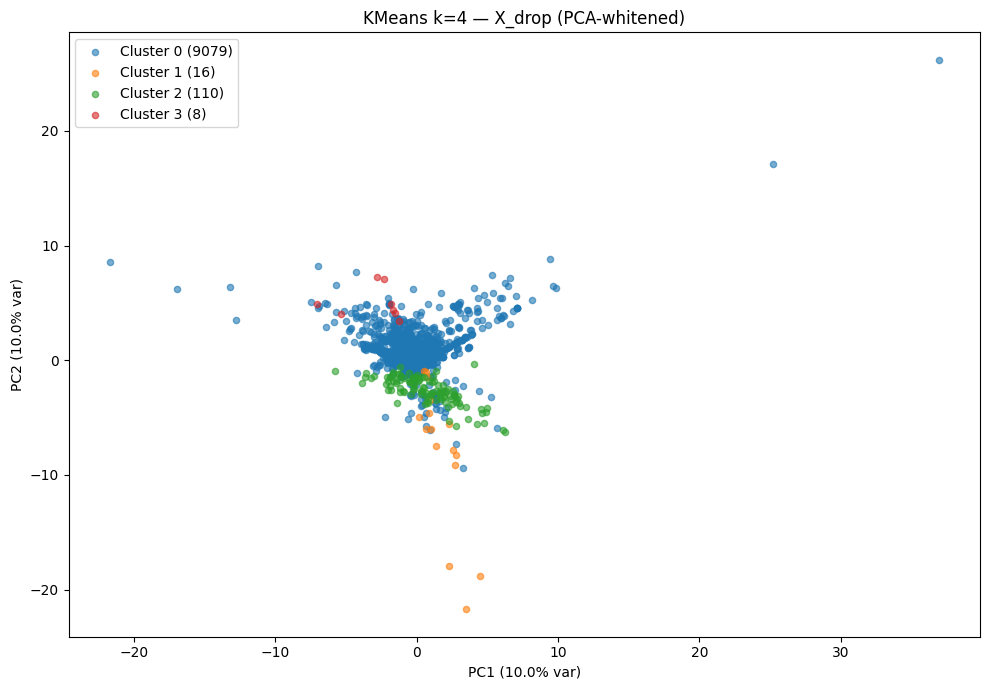


Cluster sizes:
   count    pct
0   9079  98.55
1     16   0.17
2    110   1.19
3      8   0.09


In [11]:
# Focused sweep: cap 99th percentile, try X_eng, PCA(whiten) + KMeans k=4
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

cands = {}
# base candidates
if 'datasets' in globals():
    if 'nonlog' in datasets:
        cands['nonlog'] = datasets['nonlog']
    if 'log1p' in datasets:
        cands['log1p'] = datasets['log1p']
if 'X_drop' in globals():
    cands['X_drop'] = X_drop
# engineered features
if 'X_eng' in globals():
    # scale engineered features
    scaler = RobustScaler()
    cands['X_eng'] = pd.DataFrame(scaler.fit_transform(X_eng), columns=X_eng.columns, index=X_eng.index)

# capped variants (99th percentile per feature)
for name, X in list(cands.items()):
    q99 = X.quantile(0.99)
    Xc = X.clip(upper=q99, axis=1)
    scaler = RobustScaler()
    cands[f'{name}_capped'] = pd.DataFrame(scaler.fit_transform(Xc), columns=X.columns, index=X.index)

results = []
for name, X in cands.items():
    # PCA-whitened then KMeans
    n_comp = min(10, X.shape[1])
    Xp = PCA(n_components=n_comp, whiten=True, random_state=RANDOM_STATE).fit_transform(X)
    km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30)
    labels = km.fit_predict(Xp)
    sizes = pd.Series(labels).value_counts().sort_index()
    balance = sizes.min() / sizes.sum()
    sil = np.nan
    try:
        if len(np.unique(labels)) > 1 and Xp.shape[0] > len(np.unique(labels)):
            sil = silhouette_score(Xp, labels)
    except Exception:
        sil = np.nan
    results.append({'name': name, 'sil': sil, 'balance': balance, 'sizes': sizes, 'km': km, 'labels': labels, 'Xp': Xp})

res_df = pd.DataFrame([{k: r[k] for k in ('name','sil','balance')} for r in results]).sort_values(['sil','balance'], ascending=False)
print('Strategies (silhouette, balance):')
print(res_df.to_string(index=False))

best = max(results, key=lambda r: (0 if np.isnan(r['sil']) else r['sil'], r['balance']))
print(f"\nSelected: {best['name']} — sil={best['sil']:.4f}, balance={best['balance']:.4f}")
labels_k4 = best['labels']
km4 = best['km']
Xp_best = best['Xp']

# 2D PCA visualization from the whitened Xp (project to 2D for plotting)
p2 = PCA(n_components=2, random_state=RANDOM_STATE)
coords2 = p2.fit_transform(Xp_best)
fig, ax = plt.subplots(figsize=(10,7))
colors = plt.cm.tab10
for cid in sorted(np.unique(labels_k4)):
    mask = labels_k4 == cid
    ax.scatter(coords2[mask,0], coords2[mask,1], s=20, alpha=0.6, c=[colors(cid)], label=f'Cluster {cid} ({mask.sum()})')
ax.set_xlabel(f'PC1 ({p2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({p2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'KMeans k=4 — {best["name"]} (PCA-whitened)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Print sizes
sizes = best['sizes']
print('\nCluster sizes:')
print(pd.concat([sizes, (100 * sizes / sizes.sum()).rename('pct')], axis=1).round(2))

# Save selection to globals for further exploration
_selected_kmeans = km4
_selected_labels = labels_k4
_selected_Xp = Xp_best


Best strategy:  X_drop robust raw
balance=0.0009, silhouette=0.8161, score=0.2457
cluster sizes: [9079   16  110    8]


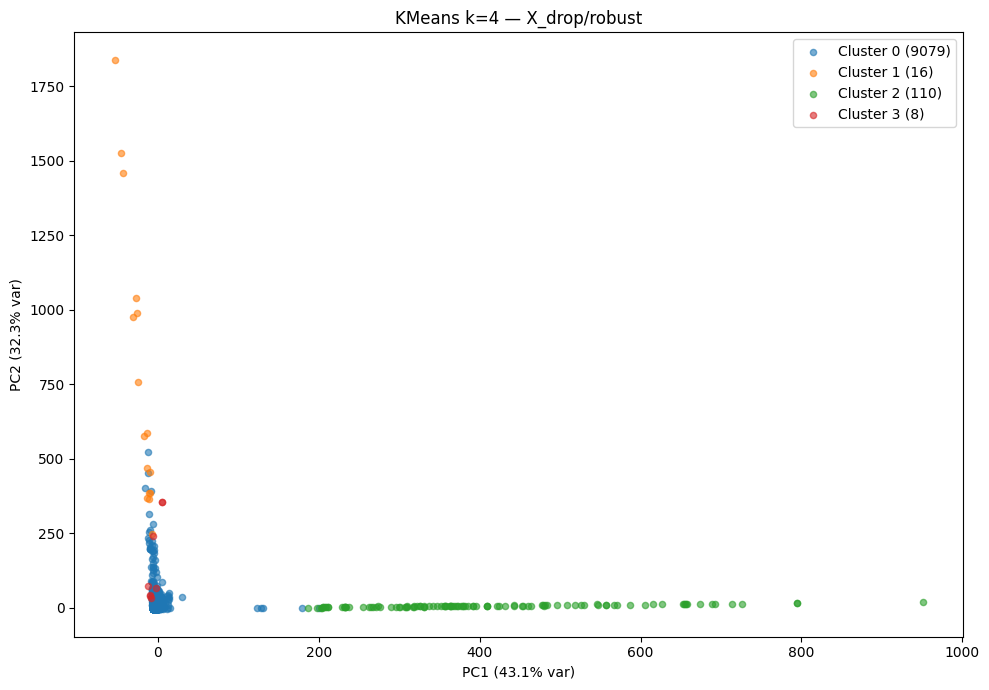

,count,pct
cluster,,
0,9079,98.55
1,16,0.17
2,110,1.19
3,8,0.09


In [12]:
# Parameter sweep: test scalers + capped variant to improve k=4 balance
from sklearn.preprocessing import RobustScaler, StandardScaler, QuantileTransformer, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt

RANDOM_STATE = 42
scalers = {
    'robust': RobustScaler(),
    'standard': StandardScaler(),
    'quantile': QuantileTransformer(output_distribution='uniform', random_state=RANDOM_STATE),
    'power': PowerTransformer()
}

# candidate matrices
cands = {}
if 'datasets' in globals():
    for k in ('log1p','nonlog'):
        if k in datasets:
            cands[k] = datasets[k]
if 'X_drop' in globals():
    cands['X_drop'] = X_drop
if 'X_eng' in globals():
    cands['X_eng'] = X_eng

best = None
for name, Xdf in cands.items():
    for sname, scaler in scalers.items():
        # original and 99th-capped
        for cap in (False, True):
            X = Xdf.copy()
            if cap:
                X = X.clip(upper=X.quantile(0.99), axis=1)
            Xs = scaler.fit_transform(X)
            # reduce dims for speed/stability
            ncomp = min(10, Xs.shape[1])
            Xp = PCA(n_components=ncomp, whiten=True, random_state=RANDOM_STATE).fit_transform(Xs)
            km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=30).fit(Xp)
            labels = km.labels_
            sizes = np.bincount(labels, minlength=4)
            if sizes.sum() == 0:
                continue
            balance = sizes.min() / sizes.sum()
            sil = np.nan
            try:
                if len(np.unique(labels))>1:
                    sil = silhouette_score(Xp, labels)
            except Exception:
                pass
            score = balance + (0 if np.isnan(sil) else 0.3 * sil)
            info = dict(name=name, scaler=sname, cap=cap, balance=balance, sil=sil, score=score, km=km, labels=labels, Xs=Xs, Xp=Xp)
            if best is None or info['score'] > best['score']:
                best = info

print('Best strategy: ', best['name'], best['scaler'], 'capped' if best['cap'] else 'raw')
print(f"balance={best['balance']:.4f}, silhouette={best['sil']:.4f}, score={best['score']:.4f}")
print('cluster sizes:', np.bincount(best['labels'], minlength=4))

# 2D PCA plot (project best Xs)
p2 = PCA(n_components=2, random_state=RANDOM_STATE)
coords = p2.fit_transform(best['Xs'])
fig, ax = plt.subplots(figsize=(10,7))
colors = plt.cm.tab10
for cid in sorted(np.unique(best['labels'])):
    mask = best['labels'] == cid
    ax.scatter(coords[mask,0], coords[mask,1], s=20, alpha=0.6, c=[colors(cid)], label=f'Cluster {cid} ({mask.sum()})')
ax.set_xlabel(f'PC1 ({p2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({p2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f"KMeans k=4 — {best['name']}/{best['scaler']}{'_capped' if best['cap'] else ''}")
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Attach labels to analysis dataframe
drop_mask = df[num_cols].notna().all(axis=1)
analysis_df = df.loc[drop_mask, num_cols].astype(float).copy()
analysis_df['cluster'] = best['labels']
if 'Descrip' in df.columns:
    analysis_df['Descrip'] = df.loc[drop_mask, 'Descrip'].values
if 'NDB_No' in df.columns:
    analysis_df['NDB_No'] = df.loc[drop_mask, 'NDB_No'].values

sizes = analysis_df['cluster'].value_counts().sort_index()
display(pd.concat([sizes, (100*sizes/sizes.sum()).rename('pct')], axis=1).round(2))

# keep globals
km4 = best['km']
labels_k4 = best['labels']
X_for_kmeans = best['Xs']

## 3.2. Agglomerative Clustering + KMeans (Tomáš)

## 3.3. DBSCAN (Eva)

# 4. Conclusion